# Return Prediction - Model Tuning Only Pipeline

이 노트북은 **데이터셋은 수정하지 않고**, 모델 코드 차원에서 성능을 개선하기 위한 전체 파이프라인입니다.

포함 내용:
- 전처리 완료 데이터 로드
- LightGBM / CatBoost / XGBoost / LogisticRegression 학습
- 클래스 가중치 적용
- 하이퍼파라미터 조정
- validation 성능 평가
- threshold tuning
- soft voting ensemble
- test 세션 분리

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss,
    balanced_accuracy_score, matthews_corrcoef,
    confusion_matrix, classification_report, brier_score_loss
)
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [2]:
# =========================
# 1. Data Load
# =========================

X_tr_unscaled = pd.read_csv("X_tr_unscaled.csv")
X_val_unscaled = pd.read_csv("X_val_unscaled.csv")
X_test_unscaled = pd.read_csv("X_test_unscaled.csv")

X_tr_scaled = pd.read_csv("X_tr_scaled.csv")
X_val_scaled = pd.read_csv("X_val_scaled.csv")
X_test_scaled = pd.read_csv("X_test_scaled.csv")

y_tr = pd.read_csv("y_tr.csv").values.ravel()
y_val = pd.read_csv("y_val.csv").values.ravel()

test_order_id = pd.read_csv("test_order_id.csv")

print("X_tr_unscaled:", X_tr_unscaled.shape)
print("X_val_unscaled:", X_val_unscaled.shape)
print("X_test_unscaled:", X_test_unscaled.shape)
print("X_tr_scaled:", X_tr_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_tr:", y_tr.shape)
print("y_val:", y_val.shape)

X_tr_unscaled: (160000, 44)
X_val_unscaled: (40000, 44)
X_test_unscaled: (50000, 44)
X_tr_scaled: (160000, 44)
X_val_scaled: (40000, 44)
X_test_scaled: (50000, 44)
y_tr: (160000,)
y_val: (40000,)


In [3]:
# =========================
# 2. Class Balance Check
# =========================

neg = int((y_tr == 0).sum())
pos = int((y_tr == 1).sum())
scale_pos_weight = neg / pos

print("negative count:", neg)
print("positive count:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 4))

negative count: 84065
positive count: 75935
scale_pos_weight: 1.1071


In [4]:
# =========================
# 3. Utility Functions
# =========================

def evaluate_model(model_name, y_true, y_pred, y_proba):
    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "log_loss": log_loss(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

    print(f"===== {model_name} =====")
    for k, v in result.items():
        if k != "model":
            print(f"{k}: {v:.4f}")

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred, zero_division=0))

    return result


def threshold_tuning(y_true, y_proba, model_name="model", start=0.20, stop=0.71, step=0.05):
    rows = []
    for th in np.arange(start, stop, step):
        pred = (y_proba >= th).astype(int)
        rows.append({
            "model": model_name,
            "threshold": round(float(th), 2),
            "accuracy": accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true, y_proba),
            "pr_auc": average_precision_score(y_true, y_proba),
        })
    return pd.DataFrame(rows).sort_values(by=["f1", "recall", "precision"], ascending=False).reset_index(drop=True)


def plot_probability_hist(y_proba, title):
    plt.figure(figsize=(7, 4))
    plt.hist(y_proba, bins=50)
    plt.title(title)
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.show()

## 4. LightGBM
데이터는 그대로 두고, 클래스 가중치/규제/트리 복잡도/early stopping만 조정합니다.

In [5]:
lgb_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=400,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=3.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_tr_unscaled, y_tr,
    eval_set=[(X_val_unscaled, y_val)],
    eval_metric="binary_logloss",
    callbacks=[
        early_stopping(stopping_rounds=30),
        log_evaluation(period=20)
    ]
)

lgb_val_proba = lgb_model.predict_proba(X_val_unscaled)[:, 1]
lgb_val_pred = (lgb_val_proba >= 0.5).astype(int)

lgb_result = evaluate_model("LightGBM_weighted", y_val, lgb_val_pred, lgb_val_proba)

Training until validation scores don't improve for 30 rounds
[20]	valid_0's binary_logloss: 0.684873
[40]	valid_0's binary_logloss: 0.682265
[60]	valid_0's binary_logloss: 0.681001
[80]	valid_0's binary_logloss: 0.68036
[100]	valid_0's binary_logloss: 0.679913
[120]	valid_0's binary_logloss: 0.679615
[140]	valid_0's binary_logloss: 0.679383
[160]	valid_0's binary_logloss: 0.679277
[180]	valid_0's binary_logloss: 0.679218
[200]	valid_0's binary_logloss: 0.679194
[220]	valid_0's binary_logloss: 0.67916
[240]	valid_0's binary_logloss: 0.679144
[260]	valid_0's binary_logloss: 0.679163
Early stopping, best iteration is:
[238]	valid_0's binary_logloss: 0.679143
===== LightGBM_weighted =====
accuracy: 0.5644
balanced_accuracy: 0.5643
precision: 0.5395
recall: 0.5612
f1: 0.5502
roc_auc: 0.5940
pr_auc: 0.5601
log_loss: 0.6791
brier_score: 0.2431
mcc: 0.1284

Confusion Matrix
[[11923  9093]
 [ 8330 10654]]

Classification Report
              precision    recall  f1-score   support

           0

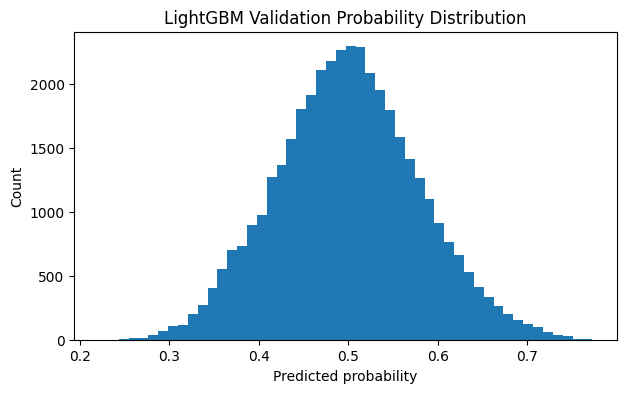

In [6]:
plot_probability_hist(lgb_val_proba, "LightGBM Validation Probability Distribution")

In [7]:
lgb_th_df = threshold_tuning(y_val, lgb_val_proba, "LightGBM")
display(lgb_th_df.head(10))

best_lgb_th = lgb_th_df.iloc[0]["threshold"]
print("Best LightGBM threshold:", best_lgb_th)

best_lgb_pred = (lgb_val_proba >= best_lgb_th).astype(int)
lgb_best_result = evaluate_model("LightGBM_best_threshold", y_val, best_lgb_pred, lgb_val_proba)

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LightGBM,0.35,0.485475,0.479479,0.982775,0.644512,0.594049,0.56005
1,LightGBM,0.30,0.476650,0.475531,0.998104,0.644161,0.594049,0.56005
2,LightGBM,0.25,0.474675,0.474634,0.999947,0.643721,0.594049,0.56005
3,LightGBM,0.20,0.474600,0.474600,1.000000,0.643700,0.594049,0.56005
4,LightGBM,0.40,0.508525,0.490544,0.922303,0.640452,0.594049,0.56005
5,LightGBM,0.45,0.542800,0.511863,0.790929,0.621508,0.594049,0.56005
6,LightGBM,0.50,0.564425,0.539525,0.561209,0.550154,0.594049,0.56005
7,LightGBM,0.55,0.567775,0.582707,0.314528,0.408539,0.594049,0.56005
8,LightGBM,0.60,0.552175,0.626806,0.139433,0.228121,0.594049,0.56005
9,LightGBM,0.65,0.536325,0.661732,0.047092,0.087927,0.594049,0.56005


Best LightGBM threshold: 0.35
===== LightGBM_best_threshold =====
accuracy: 0.4855
balanced_accuracy: 0.5095
precision: 0.4795
recall: 0.9828
f1: 0.6445
roc_auc: 0.5940
pr_auc: 0.5601
log_loss: 0.6791
brier_score: 0.2431
mcc: 0.0584

Confusion Matrix
[[  762 20254]
 [  327 18657]]

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.04      0.07     21016
           1       0.48      0.98      0.64     18984

    accuracy                           0.49     40000
   macro avg       0.59      0.51      0.36     40000
weighted avg       0.60      0.49      0.34     40000



## 5. CatBoost

In [8]:
cat_model = CatBoostClassifier(
    iterations=400,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1.0, scale_pos_weight],
    random_seed=42,
    verbose=50
)

cat_model.fit(
    X_tr_unscaled, y_tr,
    eval_set=(X_val_unscaled, y_val),
    use_best_model=True
)

cat_val_proba = cat_model.predict_proba(X_val_unscaled)[:, 1]
cat_val_pred = (cat_val_proba >= 0.5).astype(int)

cat_result = evaluate_model("CatBoost_weighted", y_val, cat_val_pred, cat_val_proba)

0:	test: 0.5758128	best: 0.5758128 (0)	total: 189ms	remaining: 1m 15s
50:	test: 0.5889652	best: 0.5889652 (50)	total: 1.62s	remaining: 11.1s
100:	test: 0.5915884	best: 0.5915884 (100)	total: 3.05s	remaining: 9.04s
150:	test: 0.5930080	best: 0.5930080 (150)	total: 4.41s	remaining: 7.27s
200:	test: 0.5934842	best: 0.5934842 (200)	total: 5.71s	remaining: 5.65s
250:	test: 0.5939615	best: 0.5939706 (249)	total: 7.27s	remaining: 4.32s
300:	test: 0.5942151	best: 0.5942151 (300)	total: 8.81s	remaining: 2.9s
350:	test: 0.5943158	best: 0.5943268 (347)	total: 10.9s	remaining: 1.53s
399:	test: 0.5944335	best: 0.5944584 (396)	total: 13s	remaining: 0us

bestTest = 0.5944584081
bestIteration = 396

Shrink model to first 397 iterations.
===== CatBoost_weighted =====
accuracy: 0.5675
balanced_accuracy: 0.5673
precision: 0.5426
recall: 0.5647
f1: 0.5534
roc_auc: 0.5945
pr_auc: 0.5608
log_loss: 0.6791
brier_score: 0.2431
mcc: 0.1345

Confusion Matrix
[[11977  9039]
 [ 8263 10721]]

Classification Report


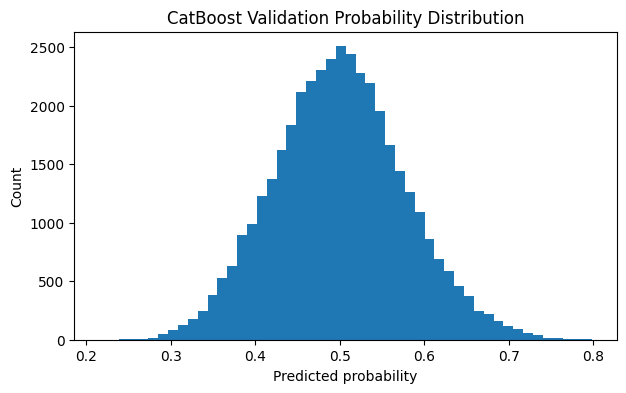

In [9]:
plot_probability_hist(cat_val_proba, "CatBoost Validation Probability Distribution")

In [10]:
cat_th_df = threshold_tuning(y_val, cat_val_proba, "CatBoost")
display(cat_th_df.head(10))

best_cat_th = cat_th_df.iloc[0]["threshold"]
print("Best CatBoost threshold:", best_cat_th)

best_cat_pred = (cat_val_proba >= best_cat_th).astype(int)
cat_best_result = evaluate_model("CatBoost_best_threshold", y_val, best_cat_pred, cat_val_proba)

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,CatBoost,0.35,0.484375,0.479013,0.986462,0.644880,0.594458,0.560837
1,CatBoost,0.30,0.476075,0.475274,0.998841,0.644079,0.594458,0.560837
2,CatBoost,0.25,0.474675,0.474636,1.000000,0.643733,0.594458,0.560837
3,CatBoost,0.20,0.474600,0.474600,1.000000,0.643700,0.594458,0.560837
4,CatBoost,0.40,0.507175,0.489880,0.929414,0.641588,0.594458,0.560837
5,CatBoost,0.45,0.540725,0.510369,0.794669,0.621552,0.594458,0.560837
6,CatBoost,0.50,0.567450,0.542561,0.564739,0.553428,0.594458,0.560837
7,CatBoost,0.55,0.568325,0.585945,0.308312,0.404031,0.594458,0.560837
8,CatBoost,0.60,0.551375,0.631021,0.131795,0.218049,0.594458,0.560837
9,CatBoost,0.65,0.535875,0.668003,0.043879,0.082349,0.594458,0.560837


Best CatBoost threshold: 0.35
===== CatBoost_best_threshold =====
accuracy: 0.4844
balanced_accuracy: 0.5086
precision: 0.4790
recall: 0.9865
f1: 0.6449
roc_auc: 0.5945
pr_auc: 0.5608
log_loss: 0.6791
brier_score: 0.2431
mcc: 0.0581

Confusion Matrix
[[  648 20368]
 [  257 18727]]

Classification Report
              precision    recall  f1-score   support

           0       0.72      0.03      0.06     21016
           1       0.48      0.99      0.64     18984

    accuracy                           0.48     40000
   macro avg       0.60      0.51      0.35     40000
weighted avg       0.60      0.48      0.34     40000



## 6. XGBoost

In [11]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.3,
    reg_lambda=3.0,
    gamma=0.1,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_tr_unscaled, y_tr,
    eval_set=[(X_val_unscaled, y_val)],
    verbose=50
)

xgb_val_proba = xgb_model.predict_proba(X_val_unscaled)[:, 1]
xgb_val_pred = (xgb_val_proba >= 0.5).astype(int)

xgb_result = evaluate_model("XGBoost_weighted", y_val, xgb_val_pred, xgb_val_proba)

[0]	validation_0-logloss:0.69262
[50]	validation_0-logloss:0.68219
[100]	validation_0-logloss:0.68010
[150]	validation_0-logloss:0.67937
[200]	validation_0-logloss:0.67910
[250]	validation_0-logloss:0.67907
[299]	validation_0-logloss:0.67904
===== XGBoost_weighted =====
accuracy: 0.5653
balanced_accuracy: 0.5652
precision: 0.5404
recall: 0.5623
f1: 0.5511
roc_auc: 0.5943
pr_auc: 0.5603
log_loss: 0.6790
brier_score: 0.2430
mcc: 0.1302

Confusion Matrix
[[11937  9079]
 [ 8309 10675]]

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.57      0.58     21016
           1       0.54      0.56      0.55     18984

    accuracy                           0.57     40000
   macro avg       0.56      0.57      0.56     40000
weighted avg       0.57      0.57      0.57     40000



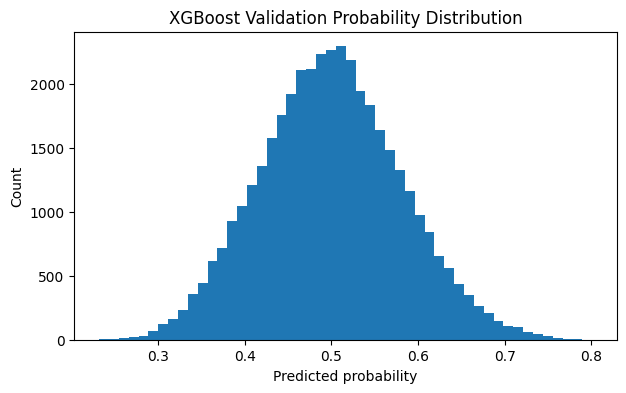

In [12]:
plot_probability_hist(xgb_val_proba, "XGBoost Validation Probability Distribution")

In [13]:
xgb_th_df = threshold_tuning(y_val, xgb_val_proba, "XGBoost")
display(xgb_th_df.head(10))

best_xgb_th = xgb_th_df.iloc[0]["threshold"]
print("Best XGBoost threshold:", best_xgb_th)

best_xgb_pred = (xgb_val_proba >= best_xgb_th).astype(int)
xgb_best_result = evaluate_model("XGBoost_best_threshold", y_val, best_xgb_pred, xgb_val_proba)

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,0.35,0.486400,0.479907,0.981353,0.644592,0.594265,0.560322
1,XGBoost,0.30,0.476500,0.475462,0.998209,0.644120,0.594265,0.560322
2,XGBoost,0.25,0.474675,0.474636,1.000000,0.643733,0.594265,0.560322
3,XGBoost,0.20,0.474600,0.474600,1.000000,0.643700,0.594265,0.560322
4,XGBoost,0.40,0.510850,0.491798,0.919142,0.640754,0.594265,0.560322
5,XGBoost,0.45,0.544075,0.512865,0.784345,0.620197,0.594265,0.560322
6,XGBoost,0.50,0.565300,0.540397,0.562316,0.551138,0.594265,0.560322
7,XGBoost,0.55,0.567875,0.580882,0.321376,0.413809,0.594265,0.560322
8,XGBoost,0.60,0.552850,0.622599,0.146861,0.237661,0.594265,0.560322
9,XGBoost,0.65,0.536850,0.659916,0.049779,0.092574,0.594265,0.560322


Best XGBoost threshold: 0.35
===== XGBoost_best_threshold =====
accuracy: 0.4864
balanced_accuracy: 0.5103
precision: 0.4799
recall: 0.9814
f1: 0.6446
roc_auc: 0.5943
pr_auc: 0.5603
log_loss: 0.6790
brier_score: 0.2430
mcc: 0.0610

Confusion Matrix
[[  826 20190]
 [  354 18630]]

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.04      0.07     21016
           1       0.48      0.98      0.64     18984

    accuracy                           0.49     40000
   macro avg       0.59      0.51      0.36     40000
weighted avg       0.60      0.49      0.35     40000



## 7. Logistic Regression
스케일된 데이터 사용.

In [14]:
lr_model = LogisticRegression(
    C=0.5,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_tr_scaled, y_tr)

lr_val_proba = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_val_pred = (lr_val_proba >= 0.5).astype(int)

lr_result = evaluate_model("LogisticRegression_weighted", y_val, lr_val_pred, lr_val_proba)

===== LogisticRegression_weighted =====
accuracy: 0.5636
balanced_accuracy: 0.5635
precision: 0.5387
recall: 0.5604
f1: 0.5494
roc_auc: 0.5881
pr_auc: 0.5550
log_loss: 0.6809
brier_score: 0.2440
mcc: 0.1268

Confusion Matrix
[[11906  9110]
 [ 8345 10639]]

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.57      0.58     21016
           1       0.54      0.56      0.55     18984

    accuracy                           0.56     40000
   macro avg       0.56      0.56      0.56     40000
weighted avg       0.56      0.56      0.56     40000



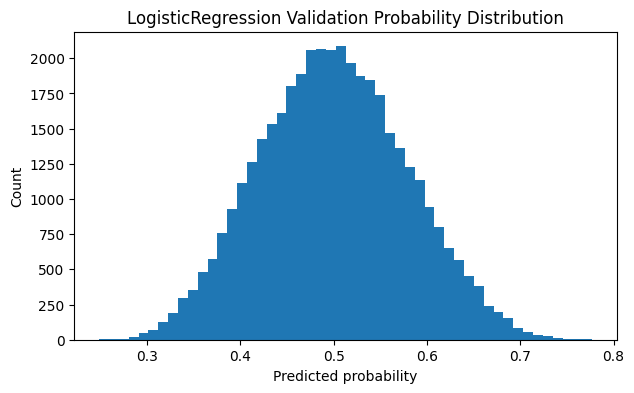

In [15]:
plot_probability_hist(lr_val_proba, "LogisticRegression Validation Probability Distribution")

In [16]:
lr_th_df = threshold_tuning(y_val, lr_val_proba, "LogisticRegression")
display(lr_th_df.head(10))

best_lr_th = lr_th_df.iloc[0]["threshold"]
print("Best LogisticRegression threshold:", best_lr_th)

best_lr_pred = (lr_val_proba >= best_lr_th).astype(int)
lr_best_result = evaluate_model("LogisticRegression_best_threshold", y_val, best_lr_pred, lr_val_proba)

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LogisticRegression,0.35,0.483825,0.478706,0.984671,0.644220,0.588133,0.554989
1,LogisticRegression,0.30,0.475375,0.474946,0.999052,0.643821,0.588133,0.554989
2,LogisticRegression,0.25,0.474625,0.474612,1.000000,0.643711,0.588133,0.554989
3,LogisticRegression,0.20,0.474600,0.474600,1.000000,0.643700,0.588133,0.554989
4,LogisticRegression,0.40,0.506075,0.489196,0.921829,0.639188,0.588133,0.554989
5,LogisticRegression,0.45,0.538400,0.508933,0.780236,0.616037,0.588133,0.554989
6,LogisticRegression,0.50,0.563625,0.538711,0.560419,0.549351,0.588133,0.554989
7,LogisticRegression,0.55,0.564125,0.572880,0.320691,0.411199,0.588133,0.554989
8,LogisticRegression,0.60,0.550650,0.615720,0.141540,0.230170,0.588133,0.554989
9,LogisticRegression,0.65,0.534950,0.657072,0.042088,0.079109,0.588133,0.554989


Best LogisticRegression threshold: 0.35
===== LogisticRegression_best_threshold =====
accuracy: 0.4838
balanced_accuracy: 0.5080
precision: 0.4787
recall: 0.9847
f1: 0.6442
roc_auc: 0.5881
pr_auc: 0.5550
log_loss: 0.6809
brier_score: 0.2440
mcc: 0.0527

Confusion Matrix
[[  660 20356]
 [  291 18693]]

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.03      0.06     21016
           1       0.48      0.98      0.64     18984

    accuracy                           0.48     40000
   macro avg       0.59      0.51      0.35     40000
weighted avg       0.59      0.48      0.34     40000



## 8. Validation Summary
threshold 0.5 기준과 best threshold 기준을 함께 비교합니다.

In [17]:
results_summary = pd.DataFrame([
    lgb_result,
    lgb_best_result,
    cat_result,
    cat_best_result,
    xgb_result,
    xgb_best_result,
    lr_result,
    lr_best_result
]).sort_values(by=["f1", "roc_auc", "pr_auc"], ascending=False).reset_index(drop=True)

display(results_summary)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,brier_score,mcc
0,CatBoost_best_threshold,0.484375,0.508648,0.479013,0.986462,0.644880,0.594458,0.560837,0.679068,0.243054,0.058080
1,XGBoost_best_threshold,0.486400,0.510328,0.479907,0.981353,0.644592,0.594265,0.560322,0.679041,0.243041,0.060961
2,LightGBM_best_threshold,0.485475,0.509517,0.479479,0.982775,0.644512,0.594049,0.560050,0.679143,0.243091,0.058402
3,LogisticRegression_best_threshold,0.483825,0.508038,0.478706,0.984671,0.644220,0.588133,0.554989,0.680906,0.243951,0.052693
4,CatBoost_weighted,0.567450,0.567319,0.542561,0.564739,0.553428,0.594458,0.560837,0.679068,0.243054,0.134474
5,XGBoost_weighted,0.565300,0.565156,0.540397,0.562316,0.551138,0.594265,0.560322,0.679041,0.243041,0.130153
6,LightGBM_weighted,0.564425,0.564270,0.539525,0.561209,0.550154,0.594049,0.560050,0.679143,0.243091,0.128383
7,LogisticRegression_weighted,0.563625,0.563470,0.538711,0.560419,0.549351,0.588133,0.554989,0.680906,0.243951,0.126786


## 9. Soft Voting Ensemble
데이터를 바꾸지 않고 모델 확률만 결합하는 방식입니다.

In [18]:
ensemble_val_proba = (
    0.5 * lgb_val_proba +
    0.3 * cat_val_proba +
    0.2 * xgb_val_proba
)

ensemble_val_pred = (ensemble_val_proba >= 0.5).astype(int)
ensemble_result = evaluate_model("Ensemble_weighted_soft_voting", y_val, ensemble_val_pred, ensemble_val_proba)

===== Ensemble_weighted_soft_voting =====
accuracy: 0.5669
balanced_accuracy: 0.5667
precision: 0.5420
recall: 0.5637
f1: 0.5527
roc_auc: 0.5948
pr_auc: 0.5609
log_loss: 0.6789
brier_score: 0.2430
mcc: 0.1333

Confusion Matrix
[[11974  9042]
 [ 8282 10702]]

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.57      0.58     21016
           1       0.54      0.56      0.55     18984

    accuracy                           0.57     40000
   macro avg       0.57      0.57      0.57     40000
weighted avg       0.57      0.57      0.57     40000



In [19]:
ensemble_th_df = threshold_tuning(y_val, ensemble_val_proba, "Ensemble")
display(ensemble_th_df.head(10))

best_ens_th = ensemble_th_df.iloc[0]["threshold"]
print("Best Ensemble threshold:", best_ens_th)

best_ens_pred = (ensemble_val_proba >= best_ens_th).astype(int)
ensemble_best_result = evaluate_model("Ensemble_best_threshold", y_val, best_ens_pred, ensemble_val_proba)

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Ensemble,0.35,0.485175,0.479362,0.984303,0.644734,0.594835,0.560917
1,Ensemble,0.30,0.476300,0.475371,0.998420,0.644080,0.594835,0.560917
2,Ensemble,0.25,0.474650,0.474624,1.000000,0.643722,0.594835,0.560917
3,Ensemble,0.20,0.474600,0.474600,1.000000,0.643700,0.594835,0.560917
4,Ensemble,0.40,0.508925,0.490795,0.925464,0.641427,0.594835,0.560917
5,Ensemble,0.45,0.542600,0.511694,0.792931,0.621999,0.594835,0.560917
6,Ensemble,0.50,0.566900,0.542038,0.563738,0.552675,0.594835,0.560917
7,Ensemble,0.55,0.568150,0.584137,0.312684,0.407329,0.594835,0.560917
8,Ensemble,0.60,0.551400,0.625422,0.136589,0.224211,0.594835,0.560917
9,Ensemble,0.65,0.536550,0.670229,0.046249,0.086528,0.594835,0.560917


Best Ensemble threshold: 0.35
===== Ensemble_best_threshold =====
accuracy: 0.4852
balanced_accuracy: 0.5093
precision: 0.4794
recall: 0.9843
f1: 0.6447
roc_auc: 0.5948
pr_auc: 0.5609
log_loss: 0.6789
brier_score: 0.2430
mcc: 0.0590

Confusion Matrix
[[  721 20295]
 [  298 18686]]

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.03      0.07     21016
           1       0.48      0.98      0.64     18984

    accuracy                           0.49     40000
   macro avg       0.59      0.51      0.36     40000
weighted avg       0.60      0.49      0.34     40000



In [20]:
final_results = pd.DataFrame([
    lgb_best_result,
    cat_best_result,
    xgb_best_result,
    lr_best_result,
    ensemble_best_result
]).sort_values(by=["f1", "roc_auc", "pr_auc"], ascending=False).reset_index(drop=True)

display(final_results)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,log_loss,brier_score,mcc
0,CatBoost_best_threshold,0.484375,0.508648,0.479013,0.986462,0.644880,0.594458,0.560837,0.679068,0.243054,0.058080
1,Ensemble_best_threshold,0.485175,0.509305,0.479362,0.984303,0.644734,0.594835,0.560917,0.678921,0.242983,0.058979
2,XGBoost_best_threshold,0.486400,0.510328,0.479907,0.981353,0.644592,0.594265,0.560322,0.679041,0.243041,0.060961
3,LightGBM_best_threshold,0.485475,0.509517,0.479479,0.982775,0.644512,0.594049,0.560050,0.679143,0.243091,0.058402
4,LogisticRegression_best_threshold,0.483825,0.508038,0.478706,0.984671,0.644220,0.588133,0.554989,0.680906,0.243951,0.052693


## 10. Test Session (No metric calculation)
test에는 정답이 없으므로 성능 지표는 계산하지 않고, 최종 선택 모델의 예측 분포만 확인합니다.

In [21]:
final_model_name = final_results.iloc[0]["model"]
print("Selected final model:", final_model_name)

if "Ensemble" in final_model_name:
    lgb_test_proba = lgb_model.predict_proba(X_test_unscaled)[:, 1]
    cat_test_proba = cat_model.predict_proba(X_test_unscaled)[:, 1]
    xgb_test_proba = xgb_model.predict_proba(X_test_unscaled)[:, 1]
    test_proba = 0.5 * lgb_test_proba + 0.3 * cat_test_proba + 0.2 * xgb_test_proba
    final_threshold = best_ens_th
elif "LightGBM" in final_model_name:
    test_proba = lgb_model.predict_proba(X_test_unscaled)[:, 1]
    final_threshold = best_lgb_th
elif "CatBoost" in final_model_name:
    test_proba = cat_model.predict_proba(X_test_unscaled)[:, 1]
    final_threshold = best_cat_th
elif "XGBoost" in final_model_name:
    test_proba = xgb_model.predict_proba(X_test_unscaled)[:, 1]
    final_threshold = best_xgb_th
else:
    test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]
    final_threshold = best_lr_th

test_pred = (test_proba >= final_threshold).astype(int)

print("Final threshold:", final_threshold)
print("Positive prediction ratio:", test_pred.mean())
print("Probability summary:")
print(pd.Series(test_proba).describe())

Selected final model: CatBoost_best_threshold
Final threshold: 0.35
Positive prediction ratio: 0.97658
Probability summary:
count    50000.000000
mean         0.499825
std          0.077389
min          0.228624
25%          0.447542
50%          0.498849
75%          0.550040
max          0.795000
dtype: float64


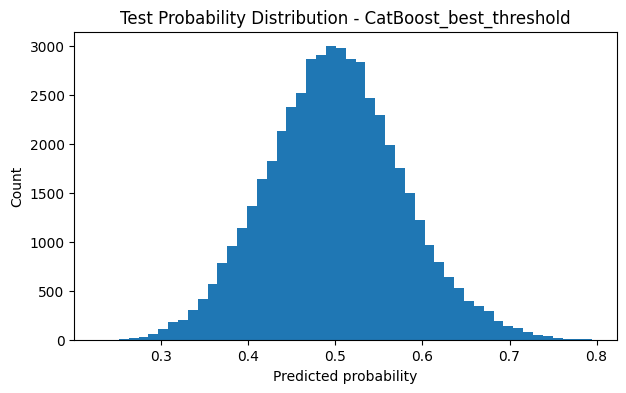

In [22]:
plt.figure(figsize=(7, 4))
plt.hist(test_proba, bins=50)
plt.title(f"Test Probability Distribution - {final_model_name}")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.show()

In [23]:
test_preview = test_order_id.copy()
test_preview["pred_proba"] = test_proba
test_preview["pred_label"] = test_pred
display(test_preview.head(20))

,order_id,pred_proba,pred_label
0,38683,0.488731,1
1,64939,0.506354,1
2,3954,0.491325,1
3,120374,0.648694,1
4,172861,0.444571,1
5,149303,0.555024,1
6,111626,0.636555,1
7,164553,0.535756,1
8,55779,0.392869,1
9,141990,0.468024,1
